In [1]:
# Critical step 1: Imports and plotting helper

import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

def show_image(title, img, cmap=None):
    plt.figure(figsize=(6, 4))
    if img.ndim == 2:  # grayscale
        plt.imshow(img, cmap=cmap or "gray")
    else:              # color, convert BGR->RGB for display
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()


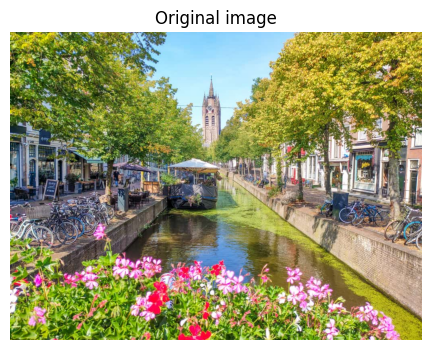

Image shape: (766, 1024, 3)


In [2]:
# Critical step 2: Load the original image from disk

image_path = "D:\\PracticeProject\\TUD_RClab\\cartoonize_rcd\\py_cartoonize_byStep\\input\\Things-to-do-in-Delft.jpg"  # <-- change this
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Could not read image at: {image_path}")

show_image("Original image", img)
print("Image shape:", img.shape)


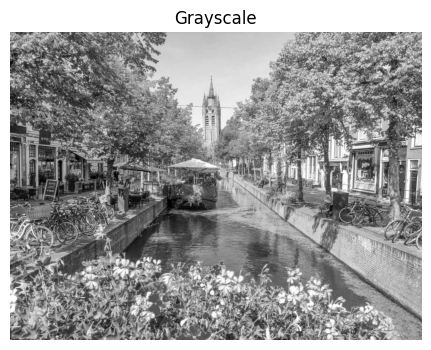

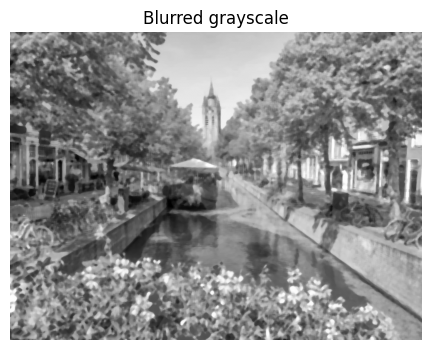

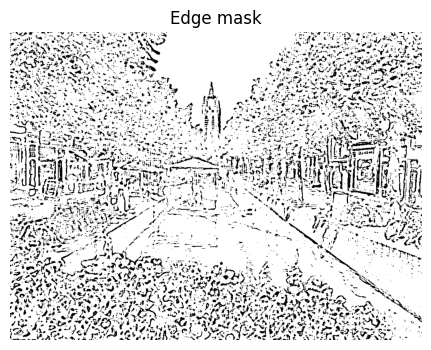

In [3]:
# Critical step 3: Create an edge mask (grayscale + median blur + adaptive threshold)

# 1. Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Median blur to reduce noise (tune kernel size: 5, 7, 9, ...)
gray_blur = cv2.medianBlur(gray, 7)

# 3. Adaptive threshold to get strong, cartoon-like edges
edges = cv2.adaptiveThreshold(
    gray_blur,
    maxValue=255,
    adaptiveMethod=cv2.ADAPTIVE_THRESH_MEAN_C,
    thresholdType=cv2.THRESH_BINARY,
    blockSize=7,  # odd number: size of neighborhood
    C=7           # constant subtracted from mean
)

show_image("Grayscale", gray, cmap="gray")
show_image("Blurred grayscale", gray_blur, cmap="gray")
show_image("Edge mask", edges, cmap="gray")


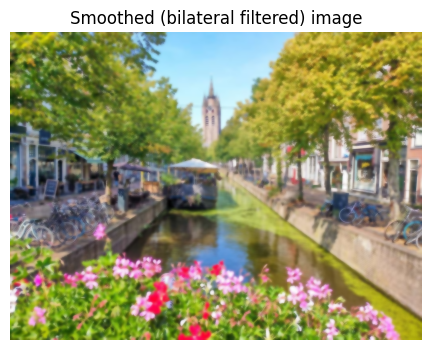

In [4]:
# Critical step 5: Apply bilateral filter to smooth colors while keeping edges

# d: neighborhood size, sigmaColor/sigmaSpace control smoothing strength
bilBlurred = cv2.bilateralFilter(
    img,
    d=10,
    sigmaColor=250,
    sigmaSpace=250
)

show_image("Smoothed (bilateral filtered) image", bilBlurred)


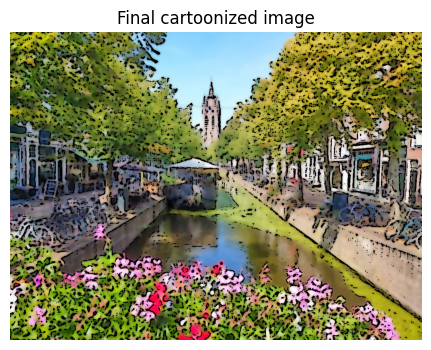

In [5]:
# Critical step 6: Combine edge mask with smoothed colors

# Ensure edges is single-channel mask, already 0/255 from adaptiveThreshold
cartoon = cv2.bitwise_and(bilBlurred, bilBlurred, mask=edges)

show_image("Final cartoonized image", cartoon)
